<a href="https://colab.research.google.com/github/JaswanthJavangula/ML_Practise/blob/main/1ML%20JAshu/XGBOOST/XGboost_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Holiday Package Prediciton

### 1) Problem statement.
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base.
One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information.
The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being.
However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.
### 2) Data Collection.
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction
The data consists of 20 column and 4888 rows.

In [6]:
## importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import os
os.environ["KAGGLE_CACHE"] = "/content/sample_data"
warnings.filterwarnings("ignore")

%matplotlib inline

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("susant4learning/holiday-package-purchase-prediction")

df= pd.read_csv("/kaggle/input/holiday-package-purchase-prediction/Travel.csv")



Using Colab cache for faster access to the 'holiday-package-purchase-prediction' dataset.


In [8]:
df.head(6)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,3.0,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


## Data Cleaning
### Handling Missing values
1. Handling Missing values
2. Handling Duplicates
3. Check data type
4. Understand the dataset

In [9]:
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,226
TypeofContact,25
CityTier,0
DurationOfPitch,251
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,45


## Label Correction

In [10]:
df['Gender'].value_counts()

,count
Gender,
Male,2916
Female,1817
Fe Male,155


In [11]:
df["Gender"] = df["Gender"].replace("Fe Male", "Female")
df["Gender"].value_counts()

,count
Gender,
Male,2916
Female,1972


In [12]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2340
Divorced,950
Single,916
Unmarried,682


In [13]:
df["MaritalStatus"] = df["MaritalStatus"].replace("Unmarried", "Single")
df["MaritalStatus"].value_counts()

,count
MaritalStatus,
Married,2340
Single,1598
Divorced,950


In [14]:
df['TypeofContact'].value_counts() #binary

,count
TypeofContact,
Self Enquiry,3444
Company Invited,1419


## Checking missing values

In [15]:
na_feature = [i for i in df.columns if df[i].isnull().sum()]
for feature in na_feature:
  print(feature,np.round(df[feature].isnull().mean()*100,4))


Age 4.6236
TypeofContact 0.5115
DurationOfPitch 5.135
NumberOfFollowups 0.9206
PreferredPropertyStar 0.5319
NumberOfTrips 2.8642
NumberOfChildrenVisiting 1.3502
MonthlyIncome 4.7668


### Imputing with mean median and mode

In [16]:
df.head(4)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0


In [17]:
df.Age.fillna(df.Age.mean(), inplace=True)
df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace=True)
df.DurationOfPitch.fillna(df.DurationOfPitch.median(),inplace=True)
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0],inplace=True)
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0],inplace=True)
df.NumberOfTrips.fillna(df.NumberOfTrips.median(),inplace=True)
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0],inplace=True)
df.MonthlyIncome.fillna(df.MonthlyIncome.median(),inplace=True)

In [18]:
df.drop('CustomerID',inplace=True,axis=1)

In [19]:
df.isnull().sum()

,0
ProdTaken,0
Age,0
TypeofContact,0
CityTier,0
DurationOfPitch,0
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,0
ProductPitched,0


## Feature Engineering

In [20]:
# removing the extra columns
df["Total Visitors"] = df["NumberOfChildrenVisiting"] + df["NumberOfPersonVisiting"]

In [21]:
df.drop(["NumberOfChildrenVisiting", "NumberOfPersonVisiting"], axis=1, inplace = True)

In [22]:
df.head(1)

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,Total Visitors
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0


In [23]:
#numerical cols
num_cols = [i for i in df.columns if df[i].dtype != "O"]
df[num_cols].head(2)

,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,MonthlyIncome,Total Visitors
0,1,41.0,3,6.0,3.0,3.0,1.0,1,2,1,20993.0,3.0
1,0,49.0,1,14.0,4.0,4.0,2.0,0,3,1,20130.0,5.0


In [24]:
#categorical cols
cat_cols  = [i for i in df.columns if df[i].dtype == "O"]
df[cat_cols].head(1)

,TypeofContact,Occupation,Gender,ProductPitched,MaritalStatus,Designation
0,Self Enquiry,Salaried,Female,Deluxe,Single,Manager


In [25]:
# Discrete cols
discrete_cols = [ i for i in num_cols if len(df[i].unique())<=25]
df[discrete_cols].head(1)

,ProdTaken,CityTier,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Total Visitors
0,1,3,3.0,3.0,1.0,1,2,1,3.0


In [26]:
continous_col = [i for i in num_cols if i not in discrete_cols]
df[continous_col].head(2)

,Age,DurationOfPitch,MonthlyIncome
0,41.0,6.0,20993.0
1,49.0,14.0,20130.0


In [27]:
# train test split
from sklearn.model_selection import train_test_split
X= df.drop(["ProdTaken"],axis=1)
y= df['ProdTaken']
X.head(2)

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,Total Visitors
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0


In [28]:
y.value_counts()

,count
ProdTaken,
0,3968
1,920


In [29]:
X.value_counts()

Age   TypeofContact    CityTier  DurationOfPitch  Occupation      Gender  NumberOfFollowups  ProductPitched  PreferredPropertyStar  MaritalStatus  NumberOfTrips  Passport  PitchSatisfactionScore  OwnCar  Designation     MonthlyIncome  Total Visitors
58.0  Self Enquiry     1         11.0             Large Business  Female  4.0                Standard        4.0                    Married        3.0            1         5                       1       Senior Manager  25552.0        3.0               2
38.0  Self Enquiry     1         10.0             Salaried        Female  4.0                Deluxe          4.0                    Single         5.0            0         4                       1       Manager         22785.0        4.0               2
31.0  Company Invited  1         7.0              Salaried        Male    5.0                Standard        3.0                    Single         3.0            0         5                       1       Senior Manager  27152.0        5.0               2
33.0  Self Enquiry     3         22.0             Small Business  Female  3.0                Deluxe          5.0                    Single         6.0            0         3                       1       Manager         20324.0        3.0               2
31.0  Company Invited  1         7.0              Small Business  Female  4.0                Deluxe          3.0                    Single         3.0            0         3                       1       Manager         22689.0        4.0               2
                                                                                                                                                                                                                                                            ..
33.0  Self Enquiry     1         14.0             Salaried        Male    3.0                Deluxe          3.0                    Single         3.0            1         3                       0       Manager         21388.0        5.0               1
                                                                          1.0                Basic           5.0                    Married        7.0            0         3                       1       Executive       18143.0        3.0               1
                                 13.0             Small Business  Male    3.0                Standard        3.0                    Married        1.0            0         4                       1       Senior Manager  26691.0        2.0               1
                                                                                                                                    Divorced       1.0            0         4                       0       Senior Manager  26691.0        2.0               1
                                 16.0             Salaried        Female  4.0                Deluxe          3.0                    Divorced       3.0            1         5                       1       Manager         25000.0        7.0               1
Name: count, Length: 4747, dtype: int64

In [30]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=42)
X_train.shape, X_test.shape

((3274, 17), (1614, 17))

In [31]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4888 non-null   float64
 1   TypeofContact           4888 non-null   object 
 2   CityTier                4888 non-null   int64  
 3   DurationOfPitch         4888 non-null   float64
 4   Occupation              4888 non-null   object 
 5   Gender                  4888 non-null   object 
 6   NumberOfFollowups       4888 non-null   float64
 7   ProductPitched          4888 non-null   object 
 8   PreferredPropertyStar   4888 non-null   float64
 9   MaritalStatus           4888 non-null   object 
 10  NumberOfTrips           4888 non-null   float64
 11  Passport                4888 non-null   int64  
 12  PitchSatisfactionScore  4888 non-null   int64  
 13  OwnCar                  4888 non-null   int64  
 14  Designation             4888 non-null   

In [32]:
#categoricing the feature columns
numerical_features = X.select_dtypes(exclude="object").columns
categorical_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
#transforming
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop ="first")

preprocessor = ColumnTransformer([
    ("OneHoteEncoder", cat_transformer, categorical_features),
    ("StandardScaler", num_transformer, numerical_features)
])

In [33]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [34]:
pd.DataFrame(X_train,columns=preprocessor.get_feature_names_out()).head()

,OneHoteEncoder__TypeofContact_Self Enquiry,OneHoteEncoder__Occupation_Large Business,OneHoteEncoder__Occupation_Salaried,OneHoteEncoder__Occupation_Small Business,OneHoteEncoder__Gender_Male,OneHoteEncoder__ProductPitched_Deluxe,OneHoteEncoder__ProductPitched_King,OneHoteEncoder__ProductPitched_Standard,OneHoteEncoder__ProductPitched_Super Deluxe,OneHoteEncoder__MaritalStatus_Married,OneHoteEncoder__MaritalStatus_Single,OneHoteEncoder__Designation_Executive,OneHoteEncoder__Designation_Manager,OneHoteEncoder__Designation_Senior Manager,OneHoteEncoder__Designation_VP,StandardScaler__Age,StandardScaler__CityTier,StandardScaler__DurationOfPitch,StandardScaler__NumberOfFollowups,StandardScaler__PreferredPropertyStar,StandardScaler__NumberOfTrips,StandardScaler__Passport,StandardScaler__PitchSatisfactionScore,StandardScaler__OwnCar,StandardScaler__MonthlyIncome,StandardScaler__Total Visitors
0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.166857,1.483420,-0.161387,1.280351,-0.725158,-0.674414,-0.637936,-0.776562,0.783328,-0.160488,0.635436
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,-1.156876,-0.708239,-0.527642,-0.721975,0.527040,-0.674414,1.567556,-0.047645,-1.276604,-1.139309,-0.780778
2,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.274387,-0.708239,0.815290,0.279188,1.779238,-0.130564,-0.637936,0.681272,0.783328,2.269527,2.051650
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.164076,-0.708239,2.036137,0.279188,-0.725158,-0.130564,1.567556,-0.047645,0.783328,1.030274,0.635436
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.495009,-0.708239,-1.015980,1.280351,0.527040,2.588687,-0.637936,-0.047645,0.783328,-0.478024,0.635436


In [35]:
!pip install xgboost

In [36]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_auc_score,precision_score, f1_score, recall_score

In [37]:
models = {
    "Logistic Regression" : LogisticRegression(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest Classifier" : RandomForestClassifier(),
    "AdaBoost Classifier" : AdaBoostClassifier(),
    "Gradient Boosting Classifier" : GradientBoostingClassifier(),
    "XGBClassifier" : XGBClassifier()
}


for i in range(len(list(models))):
   model = list(models.values())[i]
   model.fit(X_train,y_train)
#making prediction for X_train and X_test
   y_train_pred = model.predict(X_train)
   y_test_pred = model.predict(X_test)
#train perfomance
   train_acc = accuracy_score(y_train,y_train_pred)
   train_f1 = f1_score(y_train,y_train_pred)
   train_recall = recall_score(y_train,y_train_pred)
   train_precision = precision_score(y_train,y_train_pred)
   train_roc =roc_auc_score(y_train, y_train_pred)
#test perfomance
   test_acc = accuracy_score(y_test, y_test_pred)
   test_f1 = f1_score(y_test,y_test_pred)
   test_recall = recall_score(y_test,y_test_pred)
   test_precision = precision_score(y_test,y_test_pred)
   test_roc =roc_auc_score(y_test, y_test_pred)

   print(list(models.keys())[i])

   print("-"*20, "\nModel Perfomance in Training Data")
   print("- Accuracy", train_acc)
   print("- F1 Score", train_f1)
   print("- Recall", train_recall)
   print("- Precision", train_precision)
   print("- ROC AUC", train_roc)
   print("-"*20, "\nModel Perfomance in Test Data")
   print("- Accuracy", test_acc)
   print("- F1 Score", test_f1)
   print("- Recall", test_recall)
   print("- Precision", test_precision)
   print("- ROC AUC", test_roc)
   print("="*35)
   print("\n")

Logistic Regression
-------------------- 
Model Perfomance in Training Data
- Accuracy 0.8451435552840562
- F1 Score 0.43853820598006643
- Recall 0.3157894736842105
- Precision 0.717391304347826
- ROC AUC 0.6431610760940887
-------------------- 
Model Perfomance in Test Data
- Accuracy 0.8438661710037175
- F1 Score 0.41935483870967744
- Recall 0.310580204778157
- Precision 0.6453900709219859
- ROC AUC 0.6363650456139082


Decision Tree
-------------------- 
Model Perfomance in Training Data
- Accuracy 1.0
- F1 Score 1.0
- Recall 1.0
- Precision 1.0
- ROC AUC 1.0
-------------------- 
Model Perfomance in Test Data
- Accuracy 0.8928128872366791
- F1 Score 0.7140495867768595
- Recall 0.7372013651877133
- Precision 0.6923076923076923
- ROC AUC 0.8322645735855296


Random Forest Classifier
-------------------- 
Model Perfomance in Training Data
- Accuracy 1.0
- F1 Score 1.0
- Recall 1.0
- Precision 1.0
- ROC AUC 1.0
-------------------- 
Model Perfomance in Test Data
- Accuracy 0.9157372986

In [47]:

rf_params={
    "max_depth" : [5,8,15,None],
    "max_features": [5,7,"auto","log2"],
    "min_samples_split" : [2, 9,20],
    "n_estimators" : [100,200,500]
}

ada_params ={
    'n_estimators': [50,60,70,100],
    'algorithm': ['SAMME']
}

XGB_params = {
    "learning_rate"    : [0.1,0.01, 0.5],
    "max_depth"        : [5,8,15,25,None,20],
    "n_estimators"      : [100,200,500],
    "colsample_bytree" : [0.3,0.7,1,0.5]

}
# GB_params = {
#     "loss" : ['deviance', 'exponential','log_loss'],
#     "learning_rate" : [0.3,0.2, 0.5],
#     "n_estimators" : [150,200,500],
#     "max_depth" : [5,8,15,None],
#     "criterion" : ['friedman_mse', 'squared_error'],
#     "min_samples_split" : [2, 9,20]
# }

In [48]:
random_cv_models = [
    ("RF", RandomForestClassifier(), rf_params),
    ("ADA", AdaBoostClassifier(), ada_params),
    ("XGB", XGBClassifier(), XGB_params)
]

In [49]:
random_cv_models

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None],
   'max_features': [5, 7, 'auto', 'log2'],
   'min_samples_split': [2, 9, 20],
   'n_estimators': [100, 200, 500]}),
 ('ADA',
  AdaBoostClassifier(),
  {'n_estimators': [50, 60, 70, 100], 'algorithm': ['SAMME']}),
 ('XGB',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=True, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_

In [50]:
from sklearn.model_selection import RandomizedSearchCV

In [51]:
model_params= {}
for model_name , model, params in random_cv_models:
  RS_cv = RandomizedSearchCV(estimator = model,
                             param_distributions= params,
                             n_iter = 100,
                             cv = 3,
                             verbose = 2,
                             n_jobs = -1
                             )
  RS_cv.fit(X_train,y_train)
  model_params[model_name] = RS_cv.best_params_
for i in model_params:
  print(f"--------------{i}--------")
  print(model_params[i])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
--------------RF--------
{'n_estimators': 500, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}
--------------ADA--------
{'n_estimators': 100, 'algorithm': 'SAMME'}
--------------XGB--------
{'n_estimators': 500, 'max_depth': 25, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


In [52]:
models = {
    "Random Forest Classifier" : RandomForestClassifier(n_estimators= 200,
                                                        min_samples_split= 2,
                                                        max_features= 7,
                                                        max_depth= None),
    "AdaBoost Classifier" : AdaBoostClassifier(n_estimators= 100, algorithm= 'SAMME'),
    "XGB Classifier" : XGBClassifier(colsample_bytree= 0.7,
                                     learning_rate= 0.1,
                                     max_depth= 25,
                                     n_estimators= 500)
}
for i in range(len(list(models))):
   model = list(models.values())[i]
   model.fit(X_train,y_train)
#making prediction for X_train and X_test
   y_train_pred = model.predict(X_train)
   y_test_pred = model.predict(X_test)
#train perfomance
   train_acc = accuracy_score(y_train,y_train_pred)
   train_f1 = f1_score(y_train,y_train_pred)
   train_recall = recall_score(y_train,y_train_pred)
   train_precision = precision_score(y_train,y_train_pred)
   train_roc =roc_auc_score(y_train, y_train_pred)
#test perfomance
   test_acc = accuracy_score(y_test, y_test_pred)
   test_f1 = f1_score(y_test,y_test_pred)
   test_recall = recall_score(y_test,y_test_pred)
   test_precision = precision_score(y_test,y_test_pred)
   test_roc =roc_auc_score(y_test, y_test_pred)
   print(list(models.keys())[i])
   print("-"*20, "\nModel Perfomance in Training Data")
   print("- Accuracy", train_acc)
   print("- F1 Score", train_f1)
   print("- Recall", train_recall)
   print("- Precision", train_precision)
   print("- ROC AUC", train_roc)
   print("-"*20, "\nModel Perfomance in Test Data")
   print("- Accuracy", test_acc)
   print("- F1 Score", test_f1)
   print("- Recall", test_recall)
   print("- Precision", test_precision)
   print("- ROC AUC", test_roc)
   print("="*35)
   print("\n")

Random Forest Classifier
-------------------- 
Model Perfomance in Training Data
- Accuracy 1.0
- F1 Score 1.0
- Recall 1.0
- Precision 1.0
- ROC AUC 1.0
-------------------- 
Model Perfomance in Test Data
- Accuracy 0.9256505576208178
- F1 Score 0.7590361445783133
- Recall 0.6450511945392492
- Precision 0.9219512195121952
- ROC AUC 0.8164695791015701


AdaBoost Classifier
-------------------- 
Model Perfomance in Training Data
- Accuracy 0.8546120952962737
- F1 Score 0.46993318485523383
- Recall 0.3365231259968102
- Precision 0.7785977859778598
- ROC AUC 0.6569279778076231
-------------------- 
Model Perfomance in Test Data
- Accuracy 0.8482032218091697
- F1 Score 0.4262295081967213
- Recall 0.310580204778157
- Precision 0.6791044776119403
- ROC AUC 0.639014553562432


XGB Classifier
-------------------- 
Model Perfomance in Training Data
- Accuracy 1.0
- F1 Score 1.0
- Recall 1.0
- Precision 1.0
- ROC AUC 1.0
-------------------- 
Model Perfomance in Test Data
- Accuracy 0.9442379182

## AUC **Model**

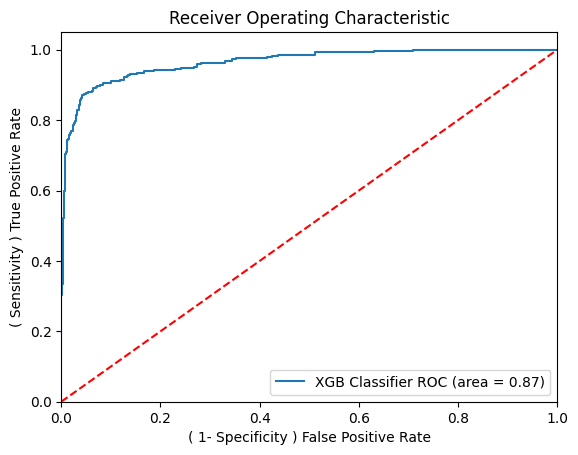

In [53]:
from sklearn.metrics import roc_curve, roc_auc_score
auc_model = [
    {
        "label" : "XGB Classifier",
        "model" : XGBClassifier(colsample_bytree= 0.7,
                                     learning_rate= 0.1,
                                     max_depth= 25,
                                     n_estimators= 500),
    # "label" : "GradientBoosting Classfier",
    # "model" : GradientBoostingClassifier(loss= 'log_loss',
    #                                                             learning_rate=0.3,
    #                                                             n_estimators=200,
    #                                                             max_depth=15,
    #                                                             criterion="friedman_mse",
    #                                                             min_samples_split=9),
    #AdaBoostClassifier(n_estimators= 100, algorithm= 'SAMME'),
    # RandomForestClassifier(n_estimators= 200,
    #                                                     min_samples_split= 2,
    #                                                     max_features= 7,
    #                                                     max_depth= None),
    "auc" :0.86633
}
]

for algo in auc_model:
  model = algo["model"]
  model.fit(X_train,y_train)

  fpr, tpr , thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])

  plt.plot(fpr,tpr,label= "%s ROC (area = %0.2f)" % (algo["label"], algo["auc"]))

plt.plot([0,1],[0,1],"r--")
plt.xlim([0.0 , 1.0])
plt.ylim([0.0,1.05])
plt.xlabel('( 1- Specificity ) False Positive Rate')
plt.ylabel('( Sensitivity ) True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show()